## **0. Library import**

In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from src.config import BRFSS_FILTERING_FILE_PATH, TRAIN_SIZE, RANDOM_STATE, \
    SGD_ALPHA, SGD_MAX_ITER, SGD_LOSS, SGD_PENALTY, SGD_LEARNING_RATE, \
    LR_C, LR_MAX_ITER, LR_SOLVER, \
    RF_N_ESTIMATORS, RF_MAX_DEPTH, \
    NB_ALPHA, NB_TYPE, NB_BINARIZE, NB_VAR_SMOOTHING
from src.evaluate import plot_roc_auc, compare_models
from src.models.sgd_classifier import DiabetesSGDClassifier
from src.models.logistic_regression import DiabetesLogisticRegression
from src.models.random_forest import DiabetesRandomForest
from src.models.naive_bayes import DiabetesNaiveBayes

## **1. Load dataset**

In [3]:
df = pd.read_csv(BRFSS_FILTERING_FILE_PATH)
df.shape

(787646, 21)

## **2. Split train and test data**

In [4]:
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (630116, 20)
X_test shape: (157530, 20)
y_train shape: (630116,)
y_test shape: (157530,)


## **3. Models**

### **3.1 SGD Classifier**

In [6]:
sgd_model = DiabetesSGDClassifier(
    loss=SGD_LOSS,
    penalty=SGD_PENALTY,
    alpha=SGD_ALPHA,
    max_iter=SGD_MAX_ITER,
    random_state=RANDOM_STATE,
    learning_rate=SGD_LEARNING_RATE
)
sgd_model_info = sgd_model.get_model_info()

2025-07-20 08:35:04,315 - [src.models.sgd_classifier] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-07-20 08:35:04,316 - [src.models.sgd_classifier] - INFO -   loss: log_loss
2025-07-20 08:35:04,317 - [src.models.sgd_classifier] - INFO -   penalty: l2
2025-07-20 08:35:04,318 - [src.models.sgd_classifier] - INFO -   alpha: 0.0001
2025-07-20 08:35:04,319 - [src.models.sgd_classifier] - INFO -   learning_rate: constant
2025-07-20 08:35:04,319 - [src.models.sgd_classifier] - INFO -   eta0: 0.01
2025-07-20 08:35:04,320 - [src.models.sgd_classifier] - INFO -   max_iter: 1000
2025-07-20 08:35:04,320 - [src.models.sgd_classifier] - INFO -   random_state: 42


In [7]:
sgd_model_info

{'loss': 'log_loss',
 'penalty': 'l2',
 'alpha': 0.0001,
 'learning_rate': 'constant',
 'eta0': 0.01,
 'max_iter': 1000,
 'random_state': 42,
 'model_path': None,
 'is_fitted': False}

In [8]:
sgd_model.train(X_train, y_train)

2025-07-20 08:35:08,595 - [src.models.sgd_classifier] - INFO - Starting SGD Classifier model training...
2025-07-20 08:35:13,391 - [src.models.sgd_classifier] - INFO - Model training completed. Training samples: 630116
2025-07-20 08:35:13,391 - [src.models.sgd_classifier] - INFO - Number of iterations: 18


In [9]:
sgd_y_pred = sgd_model.predict(X_test)

2025-07-20 08:35:13,439 - [src.models.sgd_classifier] - INFO - Predictions made for 157530 samples


In [10]:
sgd_model.evaluate(y_test, sgd_y_pred)

2025-07-20 08:35:14,177 - [src.models.sgd_classifier] - INFO - Model Evaluation Results:
2025-07-20 08:35:14,178 - [src.models.sgd_classifier] - INFO - Accuracy: 0.8345
2025-07-20 08:35:14,178 - [src.models.sgd_classifier] - INFO - Precision: 0.7744
2025-07-20 08:35:14,179 - [src.models.sgd_classifier] - INFO - Recall: 0.8345
2025-07-20 08:35:14,179 - [src.models.sgd_classifier] - INFO - F1-Score: 0.7843
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in l

{'accuracy': 0.8344886688249857,
 'precision': 0.7743751066886416,
 'recall': 0.8344886688249857,
 'f1_score': 0.7843467460950256}

In [11]:
sgd_prob = sgd_model.predict_proba(X)

2025-07-20 08:35:17,230 - [src.models.sgd_classifier] - INFO - Probabilities predicted for 787646 samples


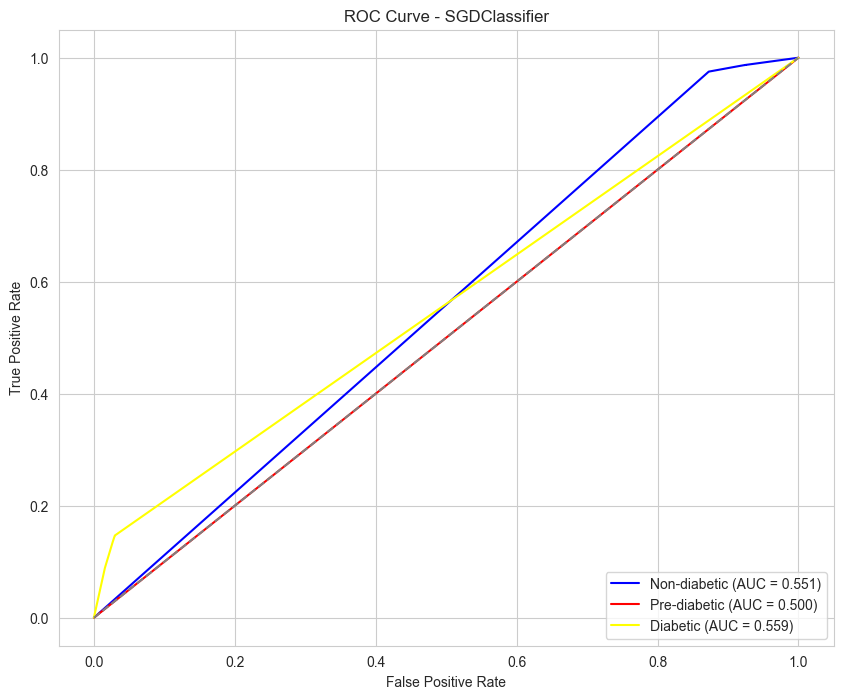

In [13]:
plot_roc_auc(y, sgd_prob, "SGDClassifier")

### **3.2 Logistic Regression**

In [17]:
lr_model = DiabetesLogisticRegression(C=LR_C, max_iter=LR_MAX_ITER, solver=LR_SOLVER)
lr_model_info = lr_model.get_model_info()

2025-07-20 08:36:51,281 - [src.models.logistic_regression] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-07-20 08:36:51,282 - [src.models.logistic_regression] - INFO -   C: 1.0
2025-07-20 08:36:51,283 - [src.models.logistic_regression] - INFO -   penalty: l2
2025-07-20 08:36:51,283 - [src.models.logistic_regression] - INFO -   solver: lbfgs
2025-07-20 08:36:51,283 - [src.models.logistic_regression] - INFO -   max_iter: 100
2025-07-20 08:36:51,284 - [src.models.logistic_regression] - INFO -   random_state: 42


In [19]:
lr_model.train(X_train, y_train)

2025-07-20 08:37:06,821 - [src.models.logistic_regression] - INFO - Starting Logistic Regression model training...
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2025-07-20 08:37:29,809 - [src.models.logistic_regression] - INFO - Model training completed. Training samples: 630116


In [20]:
lr_y_pred = lr_model.predict(X_test)

2025-07-20 08:37:29,930 - [src.models.logistic_regression] - INFO - Predictions made for 157530 samples


In [21]:
lr_model.evaluate(y_test, lr_y_pred)

2025-07-20 08:37:30,139 - [src.models.logistic_regression] - INFO - Model Evaluation Results:
2025-07-20 08:37:30,139 - [src.models.logistic_regression] - INFO - Accuracy: 0.8358
2025-07-20 08:37:30,140 - [src.models.logistic_regression] - INFO - Precision: 0.7773
2025-07-20 08:37:30,140 - [src.models.logistic_regression] - INFO - Recall: 0.8358
2025-07-20 08:37:30,141 - [src.models.logistic_regression] - INFO - F1-Score: 0.7847
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined 

{'accuracy': 0.8358154002412239,
 'precision': 0.7772776245413189,
 'recall': 0.8358154002412239,
 'f1_score': 0.7847373516683275}

In [22]:
lr_prob = lr_model.predict_proba(X)

2025-07-20 08:37:53,208 - [src.models.logistic_regression] - INFO - Probabilities predicted for 787646 samples


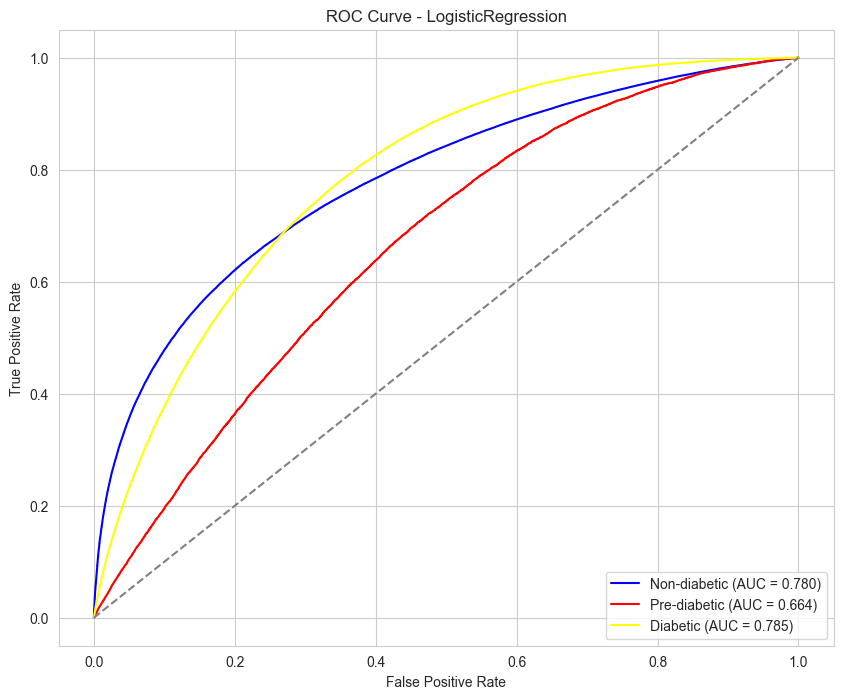

In [23]:
plot_roc_auc(y, lr_prob, "LogisticRegression")

### **3.3 Naive Bayes**

In [24]:
nb_model = DiabetesNaiveBayes(
    nb_type=NB_TYPE,
    var_smoothing=NB_VAR_SMOOTHING,
    binarize=NB_BINARIZE,
    alpha=NB_ALPHA
)
nb_model_info = nb_model.get_model_info()

2025-07-20 08:39:07,779 - [src.models.naive_bayes] - INFO - DiabetesNaiveBayes (Gaussian) initialized with parameters:
2025-07-20 08:39:07,780 - [src.models.naive_bayes] - INFO -   nb_type: gaussian
2025-07-20 08:39:07,781 - [src.models.naive_bayes] - INFO -   var_smoothing: 1e-09


In [25]:
nb_model_info

{'nb_type': 'gaussian',
 'var_smoothing': 1e-09,
 'model_path': None,
 'is_fitted': False}

In [26]:
nb_model.train(X_train, y_train)

2025-07-20 08:39:18,547 - [src.models.naive_bayes] - INFO - Starting Gaussian Naive Bayes model training...
2025-07-20 08:39:18,747 - [src.models.naive_bayes] - INFO - Model training completed. Training samples: 630116
2025-07-20 08:39:18,748 - [src.models.naive_bayes] - INFO - Number of classes: 3
2025-07-20 08:39:18,748 - [src.models.naive_bayes] - INFO - Classes: [0. 1. 2.]


In [27]:
nb_y_pred = nb_model.predict(X_test)

2025-07-20 08:39:31,082 - [src.models.naive_bayes] - INFO - Predictions made for 157530 samples


In [28]:
nb_model.evaluate(y_test, nb_y_pred)

2025-07-20 08:39:38,311 - [src.models.naive_bayes] - INFO - Model Evaluation Results:
2025-07-20 08:39:38,311 - [src.models.naive_bayes] - INFO - Accuracy: 0.7517
2025-07-20 08:39:38,312 - [src.models.naive_bayes] - INFO - Precision: 0.8013
2025-07-20 08:39:38,312 - [src.models.naive_bayes] - INFO - Recall: 0.7517
2025-07-20 08:39:38,313 - [src.models.naive_bayes] - INFO - F1-Score: 0.7689
2025-07-20 08:39:38,355 - [src.models.naive_bayes] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85    131581
         1.0       0.05      0.01      0.02      3393
         2.0       0.32      0.57      0.41     22556

    accuracy                           0.75    157530
   macro avg       0.42      0.46      0.43    157530
weighted avg       0.80      0.75      0.77    157530

2025-07-20 08:39:38,400 - [src.models.naive_bayes] - INFO - Confusion Matrix:
[[105490    623  25468]
 [  1936     41   1416]
 [  9446    219  

{'accuracy': 0.7517425252332889,
 'precision': 0.801335698960781,
 'recall': 0.7517425252332889,
 'f1_score': 0.7689339855721263}

In [29]:
nb_prob = nb_model.predict_proba(X)

2025-07-20 08:39:46,103 - [src.models.naive_bayes] - INFO - Probabilities predicted for 787646 samples


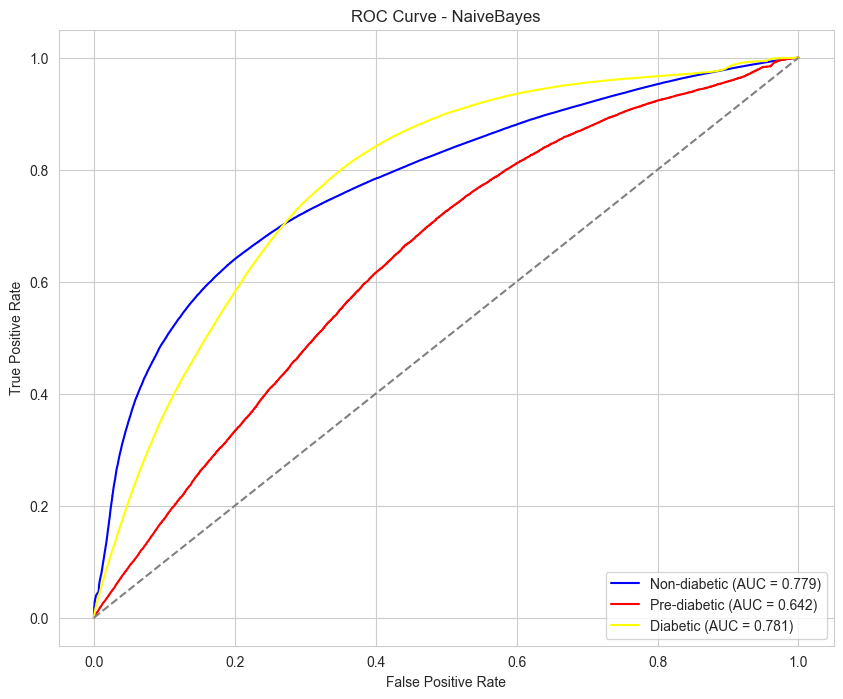

In [30]:
plot_roc_auc(y, nb_prob, "NaiveBayes")

### **3.4 Random Forest**

In [31]:
rf_model = DiabetesRandomForest(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
)
rf_model_info = rf_model.get_model_info()

2025-07-20 08:40:46,754 - [src.models.random_forest] - INFO - DiabetesRandomForest initialized with parameters:
2025-07-20 08:40:46,755 - [src.models.random_forest] - INFO -   n_estimators: 100
2025-07-20 08:40:46,756 - [src.models.random_forest] - INFO -   max_depth: 25
2025-07-20 08:40:46,756 - [src.models.random_forest] - INFO -   min_samples_split: 2
2025-07-20 08:40:46,757 - [src.models.random_forest] - INFO -   min_samples_leaf: 1
2025-07-20 08:40:46,757 - [src.models.random_forest] - INFO -   max_features: sqrt
2025-07-20 08:40:46,757 - [src.models.random_forest] - INFO -   random_state: 42


In [32]:
rf_model_info

{'n_estimators': 100,
 'max_depth': 25,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'random_state': 42,
 'model_path': None}

In [33]:
rf_model.train(X_train, y_train)

2025-07-20 08:41:06,121 - [src.models.random_forest] - INFO - Starting Random Forest model training...
2025-07-20 08:42:12,214 - [src.models.random_forest] - INFO - Model training completed. Training samples: 630116
2025-07-20 08:42:12,214 - [src.models.random_forest] - INFO - Number of trees: 100


In [34]:
rf_y_pred = rf_model.predict(X_test)

2025-07-20 08:42:16,719 - [src.models.random_forest] - INFO - Predictions made for 157530 samples


In [35]:
rf_model.evaluate(y_test, rf_y_pred)

2025-07-20 08:42:16,798 - [src.models.random_forest] - INFO - Model Evaluation Results:
2025-07-20 08:42:16,798 - [src.models.random_forest] - INFO - Accuracy: 0.8388
2025-07-20 08:42:16,799 - [src.models.random_forest] - INFO - Precision: 0.7957
2025-07-20 08:42:16,799 - [src.models.random_forest] - INFO - Recall: 0.8388
2025-07-20 08:42:16,800 - [src.models.random_forest] - INFO - F1-Score: 0.8005
2025-07-20 08:42:16,845 - [src.models.random_forest] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91    131581
         1.0       0.29      0.00      0.00      3393
         2.0       0.51      0.19      0.28     22556

    accuracy                           0.84    157530
   macro avg       0.55      0.39      0.40    157530
weighted avg       0.80      0.84      0.80    157530

2025-07-20 08:42:16,903 - [src.models.random_forest] - INFO - Confusion Matrix:
[[127847     16   3718]
 [  3040      7    346]
 [ 

{'accuracy': 0.8388116549228718,
 'precision': 0.7956970796363859,
 'recall': 0.8388116549228718,
 'f1_score': 0.8005458358516828}

In [36]:
rf_prob = rf_model.predict_proba(X)

2025-07-20 08:42:38,115 - [src.models.random_forest] - INFO - Probabilities predicted for 787646 samples


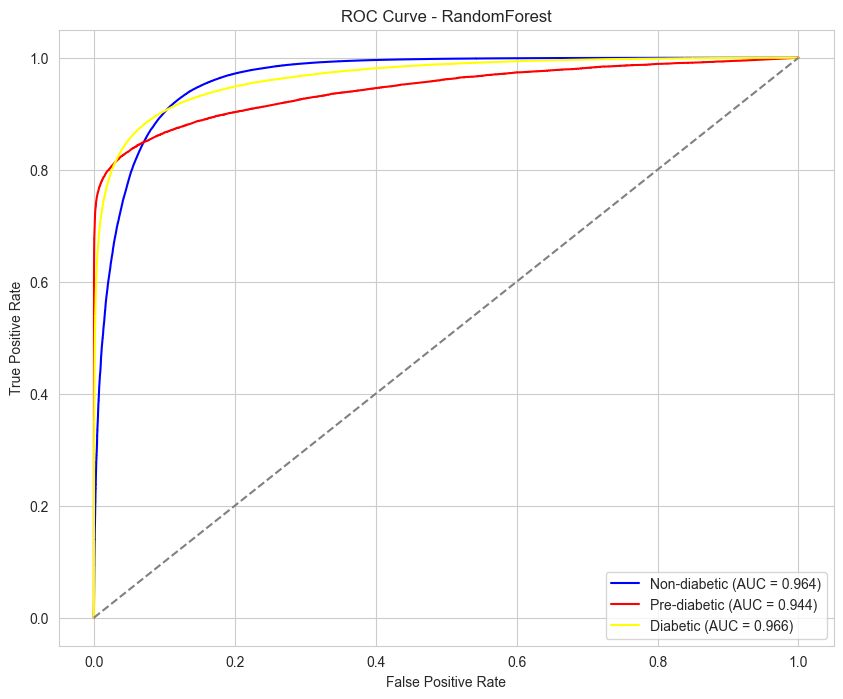

In [37]:
plot_roc_auc(y, rf_prob, "RandomForest")

## **4. Compare models**

2025-07-20 08:43:48,317 - [src.models.sgd_classifier] - INFO - Predictions made for 157530 samples
2025-07-20 08:43:48,341 - [src.models.sgd_classifier] - INFO - Probabilities predicted for 157530 samples
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/qctrung/Projects/industrial-internship/diabetes-prediction/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2025-07-20 08:43:48,504 - [src.models.log

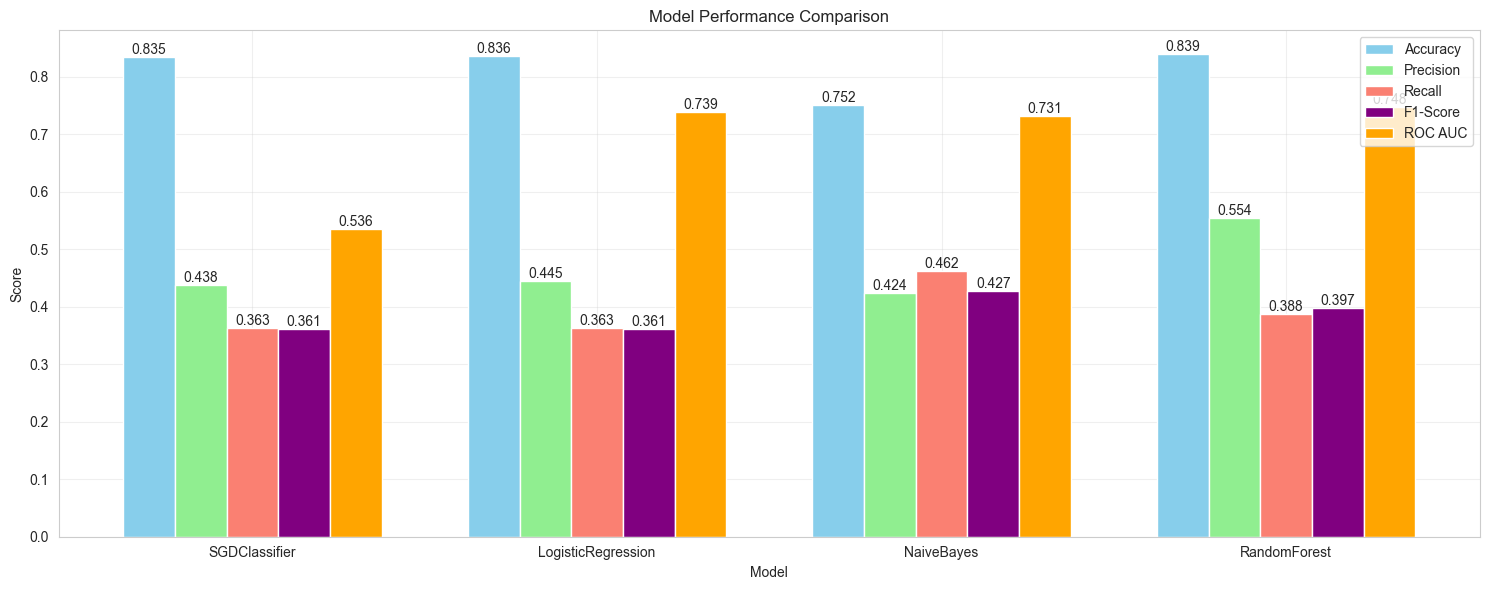

In [38]:
models = {
    "SGDClassifier": sgd_model,
    "LogisticRegression": lr_model,
    "NaiveBayes": nb_model,
    "RandomForest": rf_model
}

compare_results = compare_models(models, X_test, y_test)

In [39]:
compare_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2
0,SGDClassifier,0.8345,0.4379,0.3629,0.3615,0.5356,0.8471,0.0000,0.4666,0.9805,0.0000,0.1080,0.9090,0.0000,0.1755
1,LogisticRegression,0.8358,0.4449,0.3627,0.3611,0.7392,0.8470,0.0000,0.4877,0.9825,0.0000,0.1056,0.9097,0.0000,0.1737
2,NaiveBayes,0.7517,0.4244,0.4618,0.4273,0.7311,0.9026,0.0464,0.3241,0.8017,0.0121,0.5715,0.8492,0.0192,0.4136
3,RandomForest,0.8388,0.5540,0.3879,0.3974,0.7481,0.8571,0.2917,0.5132,0.9716,0.0021,0.1899,0.9108,0.0041,0.2772


In [40]:
df["Diabetes"].value_counts()

Diabetes
0.0    657902
2.0    112781
1.0     16963
Name: count, dtype: int64